<a href="https://colab.research.google.com/github/Srivighnesh/TensorFlow-StepUp-Projects/blob/main/TensorFlowSteup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Files

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np

Dataset Import mnist - numirical dataset includes numbers handritten images as vector form

In [115]:
mnist = tf.keras.datasets.mnist

# Load the data set, returns as (train_images, train_labels), (test_images, test_labels)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing data
Neural Network are scale sensitive so need to scale the data

In [117]:
X_train, x_test = X_train / 255.0, X_test / 255.0

In [118]:
# No need to perform on y_test. Due to picture nummber
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

# Building Neural Network

In [119]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout       # Linear layer with simple with values, weights

In [120]:
model = Sequential()
model.add(Input((28,28)))                    # Input layer with pixal size (28X28)
model.add(Flatten())                         # flatten the layer 28 * 28 = 784
model.add(Dense(128, activation="relu"))     # resoning layer dense layer with activation layer
# model.add(Dense(64, activation="relu"))    # By adding this layer it under-performance
model.add(Dropout(0.2))                      # 20% dropout chance for input
model.add(Dense(10))                         # Out as the 10 Nureons

In [121]:
nonsense_prediction  = model(X_train[:1]).numpy()
nonsense_prediction

array([[-0.3679973 , -0.3469512 , -0.5509506 ,  0.28651842, -0.10738499,
        -0.41456696,  0.17579451,  0.16939682,  0.66068417,  0.12301661]],
      dtype=float32)

By applying SOFTMAX Activation to get actuall probability

In [122]:
tf.nn.softmax(nonsense_prediction).numpy().sum()

np.float32(1.0)

Calculate Loss function

In [99]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [123]:
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
#-tf.math.log(1/10)
loss_fn(y_train[:1], nonsense_prediction)

<tf.Tensor: shape=(), dtype=float32, numpy=2.747657299041748>

In [124]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.01)

# Configures the model for training.
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics= ['accuracy']
)
# Trains the model for a fixed number of epochs (dataset iterations).
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9046 - loss: 0.3191
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9314 - loss: 0.2452
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9354 - loss: 0.2354
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9420 - loss: 0.2177
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9445 - loss: 0.2113
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9471 - loss: 0.1981
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9497 - loss: 0.2011
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9499 - loss: 0.1922
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9514 - loss: 0.1939
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9527 - loss: 0.1895


In [125]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9627 - loss: 0.2008


[0.20082898437976837, 0.9627000093460083]

In [126]:
metrics = model.get_metrics_result()

print("Evaluation")
print(f"accuracy:{metrics.get('accuracy'):.2f}")
print(f"Loss:{metrics.get('loss'):.2f}")

Evaluation
accuracy:0.96
Loss:0.20


In [134]:
prediction = model.predict(x_test)

print(prediction[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[-42.78098      8.557461   -10.884198   -19.503689    -8.091715
 -11.533246   -21.3532      -0.26363802 -11.405608   -18.385523  ]


In [135]:
predicted_digit = np.argmax(prediction[2])

print("Predicted digit:", predicted_digit)

Predicted digit: 1


In [131]:
X_test.shape

(10000, 28, 28)

To plot Correct values

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


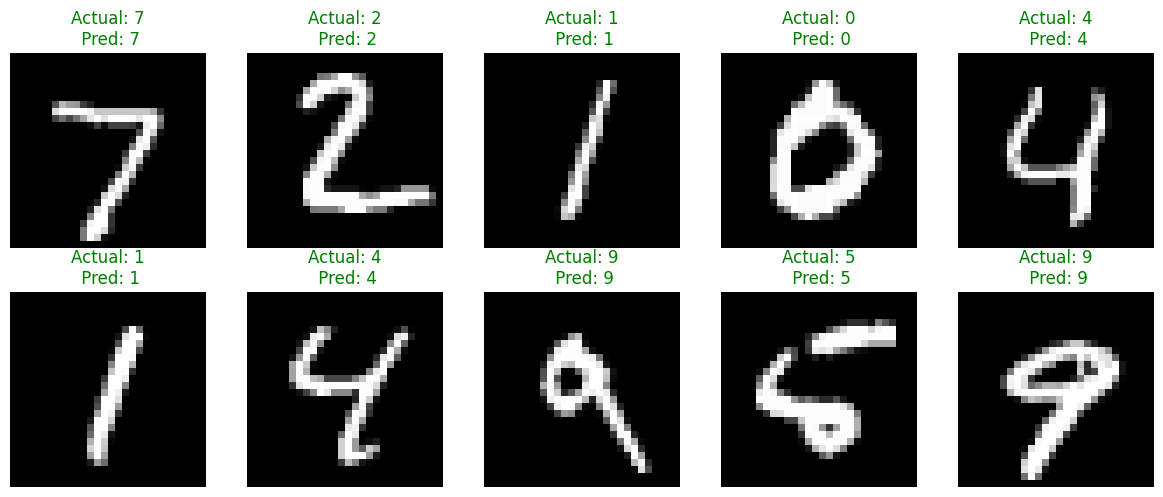

In [140]:

import matplotlib.pyplot as plt

# Make predictions
predictions = model.predict(X_test)

plt.figure(figsize=(12, 5))

for i in range(10):

    predicted_digit = np.argmax(predictions[i])
    actual_digit = y_test[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')
    plt.axis('off')

    # Green = correct, Red = wrong
    color = 'green' if predicted_digit == actual_digit else 'red'

    plt.title(
        f"Actual: {actual_digit}\n Pred: {predicted_digit}",
        color=color
    )

plt.tight_layout()
plt.show()

Plot the Wrong Prediction

total Wrong Prediction is: 373


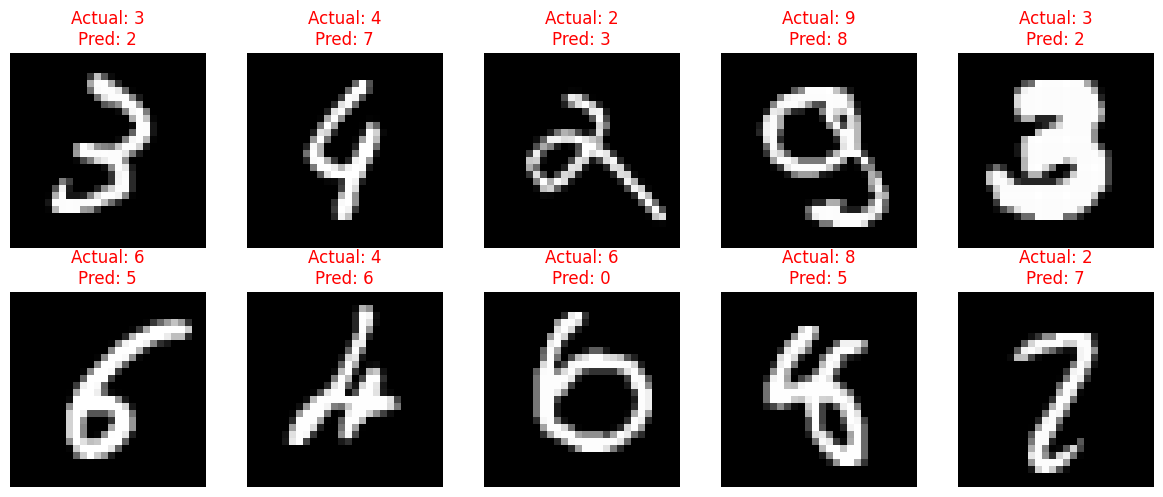

In [146]:
predicted_classes = np.argmax(prediction, axis=1)

wrong_indices = np.where(predicted_classes != y_test)[0]
print("total Wrong Prediction is:", wrong_indices.size)
plt.figure(figsize=(12, 5))

for j, index in enumerate(wrong_indices[:10]):

    plt.subplot(2, 5, j + 1)

    plt.imshow(X_test[index], cmap='gray')
    plt.axis('off')

    plt.title(
        f"Actual: {y_test[index]}\nPred: {predicted_classes[index]}",
        color='red'
    )

plt.tight_layout()
plt.show()

# Regression task - housing pricing predcition

In [36]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
df = fetch_california_housing(as_frame=True).frame

In [34]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Processing

In [55]:
scaler = StandardScaler()
X, y = df.drop('MedHouseVal', axis=1), df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [45]:
X_train_scaled.shape

(16512, 8)

Build NN

In [71]:

# Redefine the regression model for the California Housing dataset
model = Sequential()
model.add(Input(shape=(8,))) # Specify input shape as (8,) for 8 features
model.add(Dense(64, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(1)) # Output layer for regression task

# Recompile the model with the appropriate optimizer, loss, and metrics for regression
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])

history = model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.7912 - mae: 0.5997 - r2_score: 0.4051 - val_loss: 0.4615 - val_mae: 0.4706 - val_r2_score: 0.6576
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4286 - mae: 0.4533 - r2_score: 0.6777 - val_loss: 0.3901 - val_mae: 0.4423 - val_r2_score: 0.7106
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3642 - mae: 0.4315 - r2_score: 0.7261 - val_loss: 0.3832 - val_mae: 0.4432 - val_r2_score: 0.7157
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3716 - mae: 0.4230 - r2_score: 0.7206 - val_loss: 0.3625 - val_mae: 0.4266 - val_r2_score: 0.7310
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3370 - mae: 0.4097 - r2_score: 0.7466 - val_loss: 0.3527 - val_mae: 0.4131 - val_r2_score: 0.7383
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3374 - mae: 0.4052 - r2_score: 0.7463 - val_loss: 0.3408 - val_mae: 0.4026 - val_r2_score: 0.7472
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━

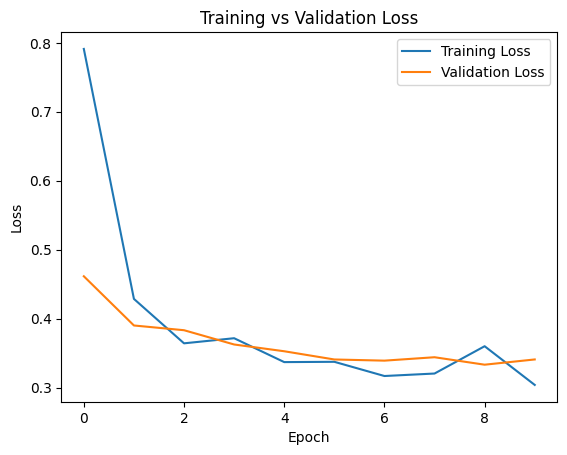

In [74]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [61]:
model.evaluate(X_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3096 - mae: 0.3832 - r2_score: 0.7661


[0.30958792567253113, 0.3831637501716614, 0.7661318778991699]

In [63]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [58]:
model.get_metrics_result()

{'loss': 0.29628434777259827, 'mae': 0.3795238435268402}

In [65]:
y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [67]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual} | Predicted: {predicted}")

Actual: 0.848 | Predicted: [1.0097597]
Actual: 0.675 | Predicted: [1.1512518]
Actual: 1.245 | Predicted: [1.3625934]
Actual: 0.975 | Predicted: [1.2878437]
Actual: 1.239 | Predicted: [1.5746837]
Actual: 1.12 | Predicted: [1.1779287]
Actual: 2.417 | Predicted: [3.2873228]
Actual: 1.633 | Predicted: [1.6724353]
Actual: 0.952 | Predicted: [1.0659912]
Actual: 0.888 | Predicted: [1.0815779]


Predict the new House value

In [77]:
new_house = pd.DataFrame([{
    'MedInc': 4.5,
    'HouseAge': 25,
    'AveRooms': 6.0,
    'AveBedrms': 1.1,
    'Population': 1200,
    'AveOccup': 3.0,
    'Latitude': 34.05,
    'Longitude': -118.25
}])
new_house_scaled = scaler.transform(new_house)
prediction = model.predict(new_house_scaled)

print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[2.5491955]]


In [78]:
predicted_value = prediction[0][0]

print("Model output:", predicted_value)
print("Predicted price: $", predicted_value * 100000)

Model output: 2.5491955
Predicted price: $ 254919.55


# Project 3: Fashion Clothing Classification

In [210]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, Y_test) = fashion_mnist.load_data()

In [208]:
fashion_mnist

<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.13/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

In [180]:
X_train.shape

(60000, 28, 28)

Look at an image

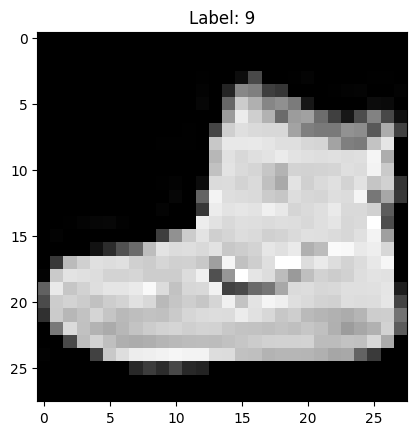

In [181]:
plt.imshow(X_train[0], cmap="grey")
plt.title(f"Label: {y_train[0]}")
plt.show()

Normalize the data

pixel values are 0–255. Convert them to 0–1:

In [183]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Build the neural network yourself

In [184]:
model = Sequential()
model.add(Input((28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics =["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6424 - loss: 1.1714 - val_accuracy: 0.7445 - val_loss: 0.7418
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7620 - loss: 0.6719 - val_accuracy: 0.7751 - val_loss: 0.6147
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7876 - loss: 0.5886 - val_accuracy: 0.7951 - val_loss: 0.5653
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8054 - loss: 0.5440 - val_accuracy: 0.8102 - val_loss: 0.5272
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8168 - loss: 0.5132 - val_accuracy: 0.8225 - val_loss: 0.5066
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8256 - loss: 0.4917 - val_accuracy: 0.8291 - val_loss: 0.4850
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8324 - loss: 0.4753 - val_accuracy: 0.8321 - val_loss: 0.4738
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8377 - loss: 0.4624 -

In [190]:
result = model.evaluate(X_test, Y_test, return_dict=True)
print(result)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8304 - loss: 0.4721
{'accuracy': 0.8303999900817871, 'loss': 0.472075879573822}


In [188]:
print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

print("Predicted:", predicted_classes[:20])
print("Actual:   ", y_test[:20])

Train accuracy: 0.8450208306312561
Validation accuracy: 0.8396666646003723
Predicted: [9 2 1 1 6 1 4 6 5 7 4 5 5 3 4 1 2 6 8 0]
Actual:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


Make the prediction

In [193]:
import numpy as np

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted:", predicted_classes[:10])
print("Actual:   ", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted: [9 2 1 1 6 1 4 6 5 7]
Actual:    [7 2 1 0 4 1 4 9 5 9]


In [215]:
index = 99

predicted_class = np.argmax(predictions[index])
confidence = np.max(predictions[index]) * 100

print("Actual:", y_test[index])
print("Predicted:", predicted_class)
print("Confidence:", confidence, "%")

Actual: 9
Predicted: 2
Confidence: 89.41721 %


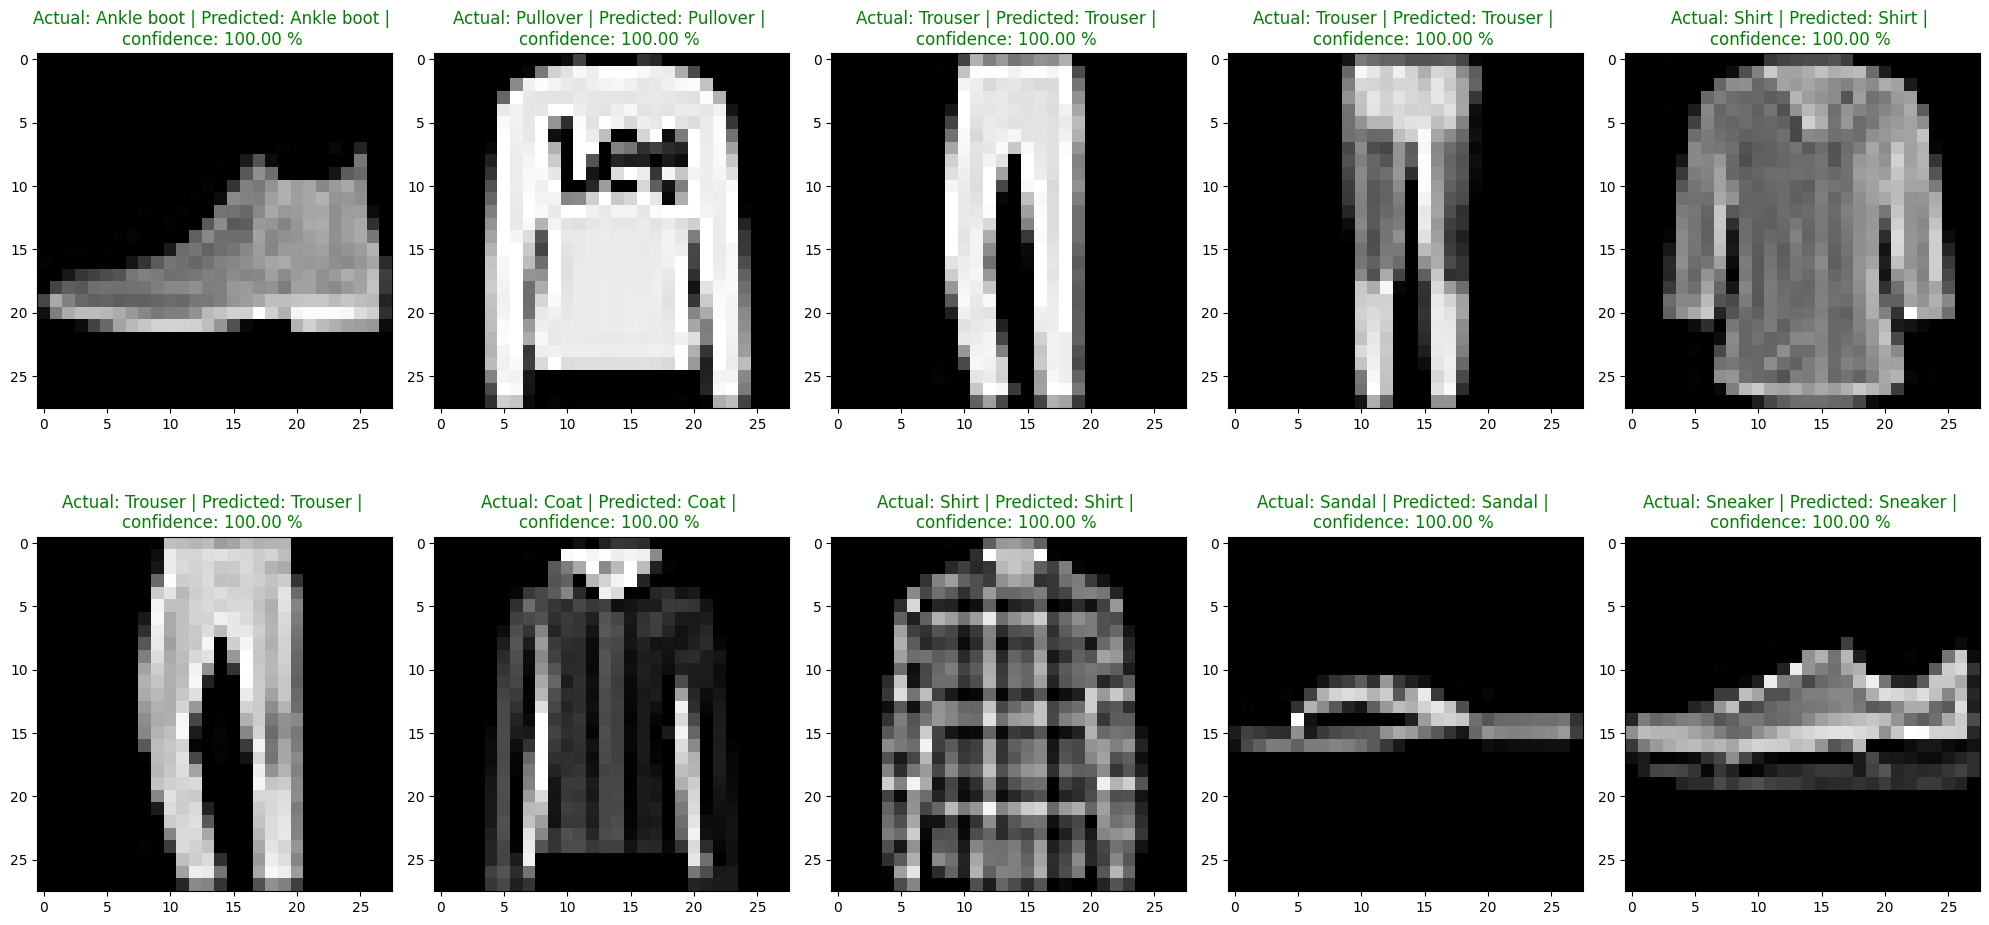

In [238]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
predicted_class = np.argmax(predictions[index])
plt.figure(figsize=(20, 10))
for idx in range(10):

  plt.subplot(2,5,idx+1)

  actual = class_names[Y_test[idx]]
  predicted = class_names[predicted_classes[idx]]
  confidence = np.max(predictions[idx]) * 100

    # Green = correct, Red = wrong
  color = 'green' if predicted == actual else 'red'
  plt.imshow(X_test[idx], cmap="gray")
  plt.title(f"Actual: {actual} | Predicted: {predicted} | \nconfidence: {confidence:.2f} % ", color = color)


plt.tight_layout()
plt.show()

total Wrong Prediction is: 1696


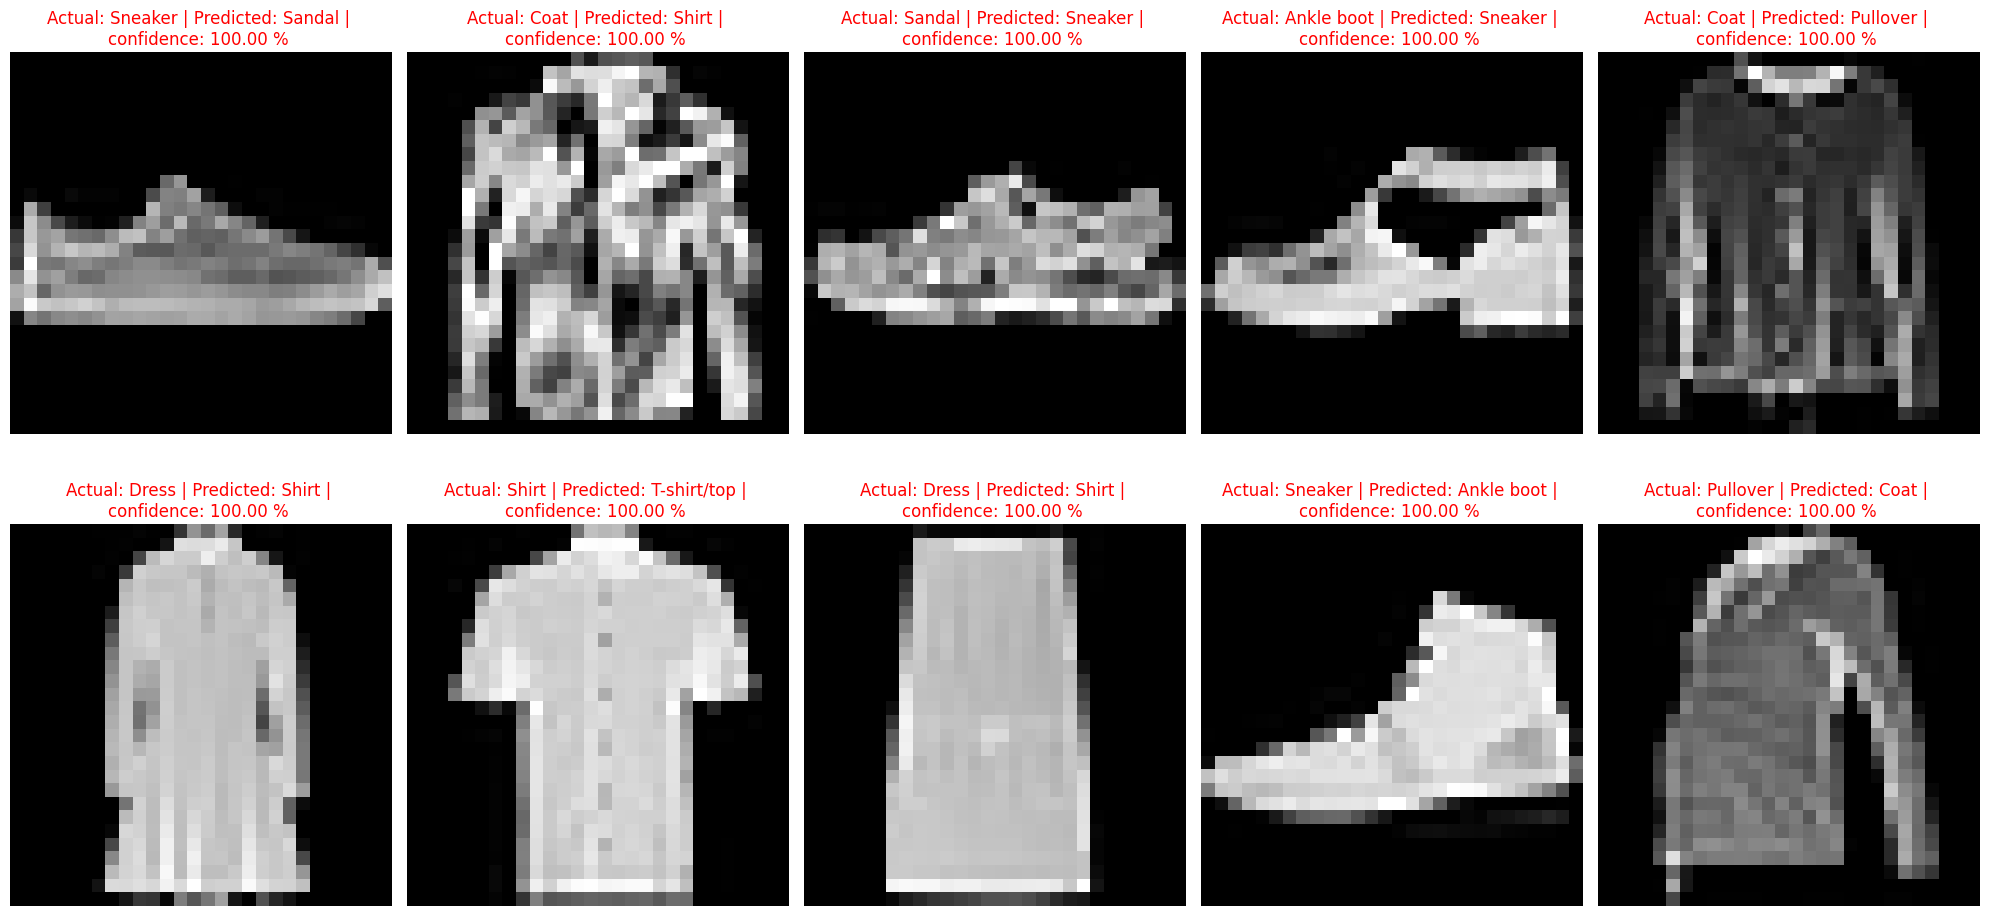

In [245]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
plt.figure(figsize=(20, 10))

# `predicted_classes` contains all model predictions. Use it to find wrong predictions.
wrong_indices = np.where(predicted_classes != Y_test)[0]
print("total Wrong Prediction is:", wrong_indices.size)

for j, index in enumerate(wrong_indices[:10]):

    plt.subplot(2, 5, j + 1)
    # Use `index` (the loop variable) to access the correct actual and predicted values
    actual = class_names[Y_test[index]]
    predicted = class_names[predicted_classes[index]]
    confidence = np.max(predictions[idx]) * 100

    plt.imshow(X_test[index], cmap='gray')
    plt.axis('off')

    plt.title(f"Actual: {actual} | Predicted: {predicted} | \nconfidence: {confidence:.2f} % ", color = 'red')

plt.tight_layout()
plt.show()